# 04 — Model Evaluation

In [1]:
!pip install -q lightgbm optuna pytorch-forecasting==1.1.1 lightning numpy==1.26.4 pandas==2.1.4
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 33.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
tobler 0.14

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
torch.set_float32_matmul_precision('medium')

import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')

DRIVE_DATA = '/content/drive/MyDrive/predictamarket/data'
MODEL_DIR = '/content/drive/MyDrive/predictamarket/models'
EVAL_DIR = '/content/drive/MyDrive/predictamarket/evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)

In [ ]:
CHECKPOINT_NAME = "tft-epoch=05-val_loss=9.3008.ckpt"

import re as _re
_ckpts_avail = sorted([f for f in os.listdir(MODEL_DIR) if f.endswith('.ckpt')])
if CHECKPOINT_NAME is None:
    CHECKPOINT_NAME = _ckpts_avail[-1]
assert CHECKPOINT_NAME in _ckpts_avail, f'{CHECKPOINT_NAME} not among {_ckpts_avail}'

_m = _re.search(r'epoch=?(\d+)', CHECKPOINT_NAME)
RUN_TAG = f'epoch{int(_m.group(1)):02d}' if _m else CHECKPOINT_NAME.replace('.ckpt', '')

EVAL_DIR = os.path.join(EVAL_DIR, RUN_TAG)
os.makedirs(EVAL_DIR, exist_ok=True)

print(f'Available checkpoints ({len(_ckpts_avail)}):')
for c in _ckpts_avail:
    print(f'  {"→" if c == CHECKPOINT_NAME else " "} {c}')
print(f'\nUsing:   {CHECKPOINT_NAME}')
print(f'RUN_TAG: {RUN_TAG}')
print(f'Outputs → {EVAL_DIR}')


Available checkpoints (7):
    tft-epoch=00-val_loss=8.9736.ckpt
    tft-epoch=01-val_loss=7.3249.ckpt
    tft-epoch=02-val_loss=8.8051.ckpt
    tft-epoch=03-val_loss=8.2107.ckpt
    tft-epoch=04-val_loss=9.2586.ckpt
  → tft-epoch=05-val_loss=9.3008.ckpt
    tft-epoch=06-val_loss=9.4489.ckpt

Using:   tft-epoch=05-val_loss=9.3008.ckpt
RUN_TAG: epoch05
Outputs → /content/drive/MyDrive/predictamarket/evaluation/epoch05


In [ ]:
with open(os.path.join(MODEL_DIR, 'config.json')) as f:
    config = json.load(f)
with open(os.path.join(MODEL_DIR, 'training_dataset_params.pkl'), 'rb') as f:
    dataset_params = pickle.load(f)

known_tickers = list(dataset_params['categorical_encoders']['__group_id__ticker'].classes_.keys())
max_encoder_length = dataset_params.get('max_encoder_length', 60)

# Read only needed tickers directly from parquet (never loads full 11M rows)
import pyarrow.parquet as pq

train_table = pq.read_table(
    os.path.join(DRIVE_DATA, 'train.parquet'),
    filters=[('ticker', 'in', known_tickers)]
)
train_df = train_table.to_pandas()
del train_table
train_df = train_df.groupby('ticker').tail(max_encoder_length + 30).copy()
print(f'Train tail: {train_df.shape}')

test_df = pd.read_parquet(os.path.join(DRIVE_DATA, 'test.parquet'))
test_df = test_df[test_df['ticker'].isin(known_tickers)].copy()
print(f'Test: {test_df.shape}')

import gc; gc.collect()

for col in config['static_categoricals'] + config['time_varying_known_categoricals']:
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)
train_df['time_idx'] = train_df['time_idx'].astype(int)
test_df['time_idx'] = test_df['time_idx'].astype(int)
train_df[config['time_varying_unknown_reals']] = train_df[config['time_varying_unknown_reals']].fillna(0)
test_df[config['time_varying_unknown_reals']] = test_df[config['time_varying_unknown_reals']].fillna(0)

for df in [train_df, test_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['Close'], inplace=True)
    df.drop(df[df['Close'] <= 0].index, inplace=True)

for col in train_df.columns:
    if col not in test_df.columns:
        test_df[col] = 0.0
test_df = test_df[train_df.columns]

test_with_history = pd.concat([train_df, test_df], ignore_index=True)
test_with_history = test_with_history.drop_duplicates(subset=['ticker', 'time_idx']).sort_values(['ticker', 'time_idx']).reset_index(drop=True)

test_start_idx = int(test_df['time_idx'].min())

params = dataset_params.copy()
params['allow_missing_timesteps'] = True
training = TimeSeriesDataSet.from_parameters(params, train_df)
try:
    test_ds = TimeSeriesDataSet.from_dataset(
        training, test_with_history,
        predict=False, stop_randomization=True,
        min_prediction_idx=test_start_idx,
    )
except TypeError:
    # Fallback: older version without min_prediction_idx kw
    test_ds = TimeSeriesDataSet.from_dataset(
        training, test_with_history,
        predict=False, stop_randomization=True,
    )
test_dl = test_ds.to_dataloader(train=False, batch_size=128, num_workers=4)

# Per-window prev_close lookup for naive baseline (sliding windows need different prev_close per window!)
close_lookup = dict(zip(
    zip(test_with_history['ticker'], test_with_history['time_idx']),
    test_with_history['Close']
))

# Load the checkpoint selected in the config cell above
model = TemporalFusionTransformer.load_from_checkpoint(
    os.path.join(MODEL_DIR, CHECKPOINT_NAME), weights_only=False
)
print(f'Model loaded from: {CHECKPOINT_NAME}')
print(f'Test samples: {len(test_ds)}  (was 400 with predict=True)')
print(f'Tickers: {len(known_tickers)}')


Train tail: (36000, 115)
Test: (41600, 115)
Model loaded from: tft-epoch=05-val_loss=9.3008.ckpt
Test samples: 9200  (was 400 with predict=True)
Tickers: 400


## Predictions

In [ ]:
raw_output = model.predict(test_dl, mode='raw')
pred_with_idx = model.predict(test_dl, return_x=True, return_index=True)

quantiles = raw_output['prediction'].detach().cpu().numpy()
median = quantiles[:, :, 3]  # q=0.5
lower = quantiles[:, :, 1]   # q=0.1
upper = quantiles[:, :, 5]   # q=0.9
actuals = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()
idx = pred_with_idx.index

print(f'Predictions: {median.shape}')
print(f'Actuals: {actuals.shape}')

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Predictions: (9200, 22)
Actuals: (9200, 22)


## Per-Horizon metrics

In [ ]:
def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

horizons = {'1d': 0, '3d': 2, '5d': 4, '22d': 21}
max_step = config['max_prediction_length']

results = []
for h_name, step in horizons.items():
    if step >= max_step: continue
    actual_h = actuals[:, step]
    pred_h = median[:, step]
    valid = actual_h > 0

    if step == 0:
        # 1d: use step 0 vs step 1 direction
        if max_step > 1:
            actual_dir = np.sign(actuals[:, 1] - actuals[:, 0])
            pred_dir = np.sign(median[:, 1] - median[:, 0])
            dir_accuracy = np.mean(actual_dir == pred_dir)
        else:
            dir_accuracy = np.nan
    else:
        # Multi-day: average day-over-day DirAcc across all steps up to horizon
        correct = []
        for t in range(1, step + 1):
            actual_dir = np.sign(actuals[:, t] - actuals[:, t-1])
            pred_dir = np.sign(median[:, t] - median[:, t-1])
            correct.append(np.mean(actual_dir == pred_dir))
        dir_accuracy = np.mean(correct)

    results.append({
        'horizon': h_name,
        'MAE': mean_absolute_error(actual_h[valid], pred_h[valid]),
        'RMSE': np.sqrt(mean_squared_error(actual_h[valid], pred_h[valid])),
        'MAPE': mape(actual_h[valid], pred_h[valid]),
        'DirAcc': round(dir_accuracy, 3),
        'CI_Coverage': np.mean((actual_h >= lower[:, step]) & (actual_h <= upper[:, step])),
    })

metrics_df = pd.DataFrame(results)
display(metrics_df.round(3))
metrics_df.to_csv(os.path.join(EVAL_DIR, 'aggregate_metrics.csv'), index=False)


,horizon,MAE,RMSE,MAPE,DirAcc,CI_Coverage
0,1d,15.926,63.001,4.861,0.480,0.712
1,3d,18.352,66.539,6.051,0.499,0.679
2,5d,20.441,70.503,6.986,0.503,0.677
3,22d,33.775,104.033,12.653,0.512,0.656


## Sector analysis

,mean_MAPE,n_tickers
sector,,
Energy,2.305,19
Real Estate,2.315,23
Consumer Defensive,2.386,25
Utilities,2.488,26
Financial Services,2.777,59
Communication Services,3.026,13
Healthcare,3.179,39
Basic Materials,3.969,19
Consumer Cyclical,5.506,46


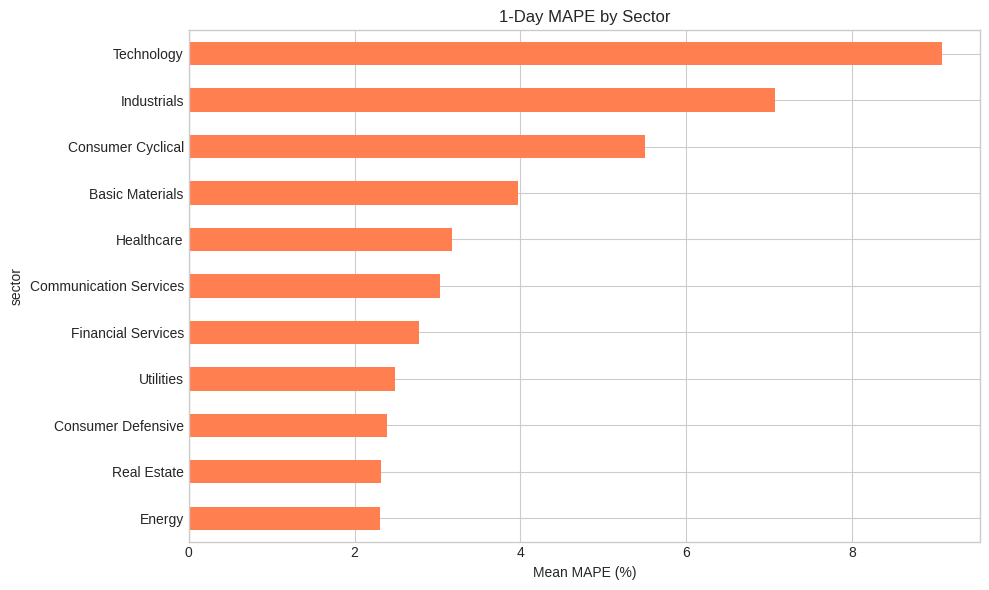

In [9]:
tickers = sorted(idx['ticker'].unique())
sector_results = []
for ticker in tickers:
    mask = (idx['ticker'] == ticker).values.nonzero()[0]
    if len(mask) == 0: continue
    a, p = actuals[mask, 0], median[mask, 0]
    v = a > 0
    if v.sum() < 1: continue
    sector_results.append({
        'ticker': ticker,
        'sector': config['sectors'].get(ticker, 'N/A'),
        'MAPE_1d': mape(a[v], p[v]),
    })

sector_df = pd.DataFrame(sector_results)
sector_agg = sector_df.groupby('sector').agg(
    mean_MAPE=('MAPE_1d', 'mean'),
    n_tickers=('ticker', 'count')
).sort_values('mean_MAPE')

display(sector_agg.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
sector_agg['mean_MAPE'].plot.barh(ax=ax, color='coral')
ax.set_xlabel('Mean MAPE (%)')
ax.set_title('1-Day MAPE by Sector')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'sector_mape.png'), dpi=100)
plt.show()


## Baseline comparison and plots

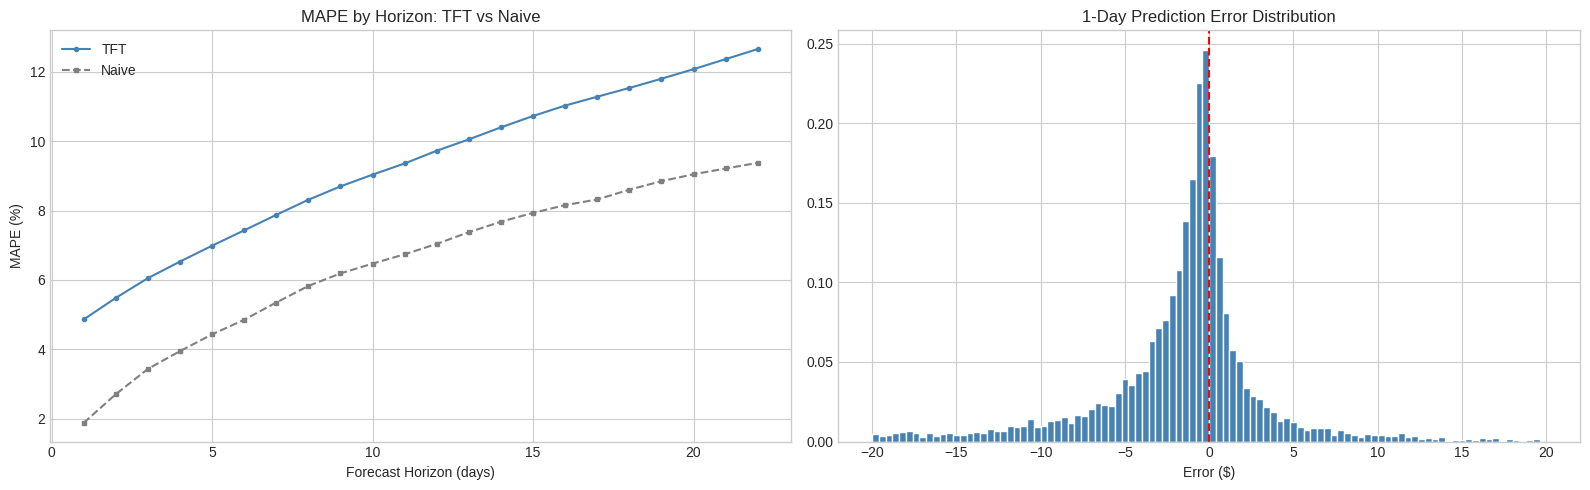

In [ ]:
naive_close = np.array([
    close_lookup.get((t, ti - 1), np.nan)
    for t, ti in zip(idx['ticker'].values, idx['time_idx'].values)
])
naive_close = np.where(np.isnan(naive_close), actuals[:, 0], naive_close)

tft_mapes = []
naive_mapes = []
for step in range(max_step):
    a, p = actuals[:, step], median[:, step]
    v = a > 0
    tft_mapes.append(mape(a[v], p[v]))
    naive_mapes.append(mape(a[v], naive_close[v]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(range(1, max_step+1), tft_mapes, 'o-', color='steelblue', label='TFT', ms=3)
ax.plot(range(1, max_step+1), naive_mapes, 's--', color='gray', label='Naive', ms=3)
ax.set_xlabel('Forecast Horizon (days)')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE by Horizon: TFT vs Naive')
ax.legend()

ax = axes[1]
errors = median[:, 0] - actuals[:, 0]
ax.hist(errors, bins=100, color='steelblue', edgecolor='white', density=True, range=(-20, 20))
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Error ($)')
ax.set_title('1-Day Prediction Error Distribution')

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'mape_and_errors.png'), dpi=150)
plt.show()


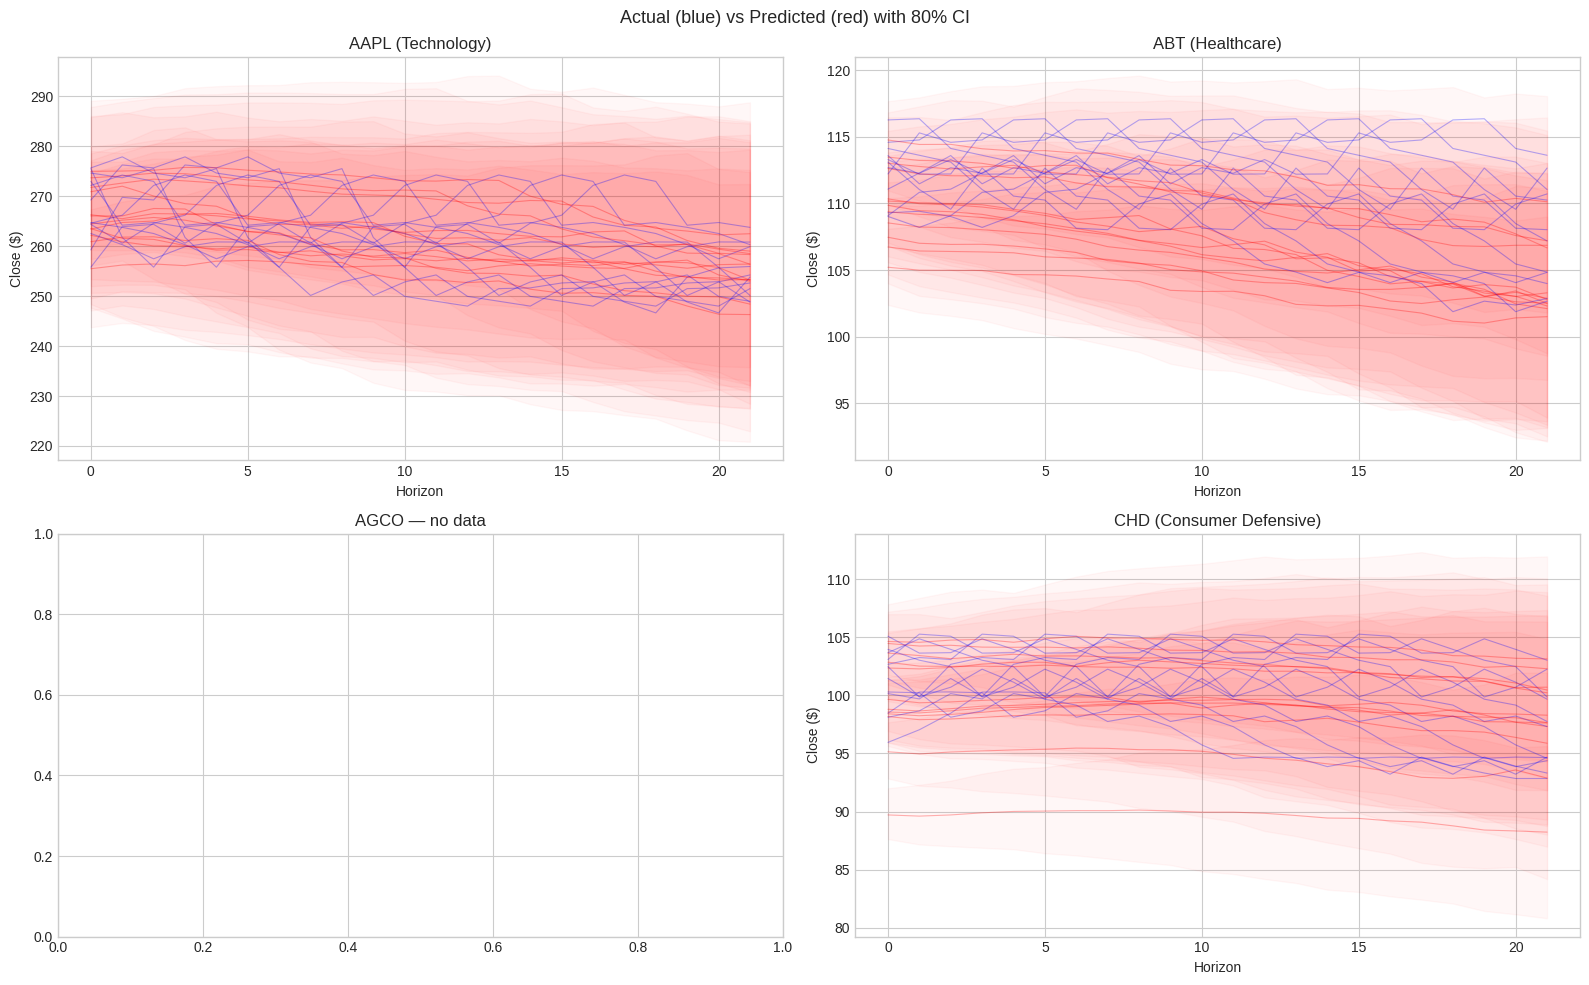

In [ ]:
plot_tickers = ['aapl', 'abt', 'agco', 'chd']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, ticker in zip(axes.flat, plot_tickers):
    mask = (idx['ticker'] == ticker).values.nonzero()[0]
    if len(mask) == 0:
        ax.set_title(f'{ticker.upper()} — no data')
        continue
    for i in mask[::max(1, len(mask)//10)]:
        steps = np.arange(max_step)
        ax.plot(steps, actuals[i], 'b-', alpha=0.3, lw=0.8)
        ax.plot(steps, median[i], 'r-', alpha=0.3, lw=0.8)
        ax.fill_between(steps, lower[i], upper[i], alpha=0.03, color='red')
    ax.set_title(f'{ticker.upper()} ({config["sectors"].get(ticker, "")})')
    ax.set_xlabel('Horizon')
    ax.set_ylabel('Close ($)')

plt.suptitle('Actual (blue) vs Predicted (red) with 80% CI', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'sample_predictions.png'), dpi=150)
plt.show()

## Calibration

In [12]:
quantile_pairs = [(0, 6, 0.96), (1, 5, 0.80), (2, 4, 0.50)]

print('=== Prediction Interval Calibration ===')
for h_name, step in [('1-day', 0), ('5-day', 4), ('22-day', 21)]:
    if step >= max_step: continue
    print(f'\n{h_name}:')
    for q_low, q_high, expected in quantile_pairs:
        lo = quantiles[:, step, q_low]
        hi = quantiles[:, step, q_high]
        coverage = np.mean((actuals[:, step] >= lo) & (actuals[:, step] <= hi))
        width = np.mean(hi - lo)
        status = 'OK' if abs(coverage - expected) < 0.1 else 'DRIFT'
        print(f'  Expected {expected*100:.0f}% -> Actual {coverage*100:.1f}% (width ${width:.2f}) [{status}]')

print(f'\n=== Evaluation Complete ===')
print(f'Saved to: {EVAL_DIR}')

=== Prediction Interval Calibration ===

1-day:
  Expected 96% -> Actual 87.5% (width $39.27) [OK]
  Expected 80% -> Actual 71.2% (width $23.01) [OK]
  Expected 50% -> Actual 47.0% (width $10.91) [OK]

5-day:
  Expected 96% -> Actual 86.1% (width $50.90) [OK]
  Expected 80% -> Actual 67.7% (width $29.86) [DRIFT]
  Expected 50% -> Actual 41.1% (width $14.49) [OK]

22-day:
  Expected 96% -> Actual 87.1% (width $93.16) [OK]
  Expected 80% -> Actual 65.6% (width $53.86) [DRIFT]
  Expected 50% -> Actual 40.6% (width $26.91) [OK]

=== Evaluation Complete ===
Saved to: /content/drive/MyDrive/predictamarket/evaluation/epoch05


## Compare All Checkpoints

EarlyStopping выбирал best по `val_loss` на `predict=True` (400 samples = шумная метрика). Здесь прогоняем **все сохранённые чекпоинты** через test set и смотрим честные метрики. Лучшая эпоха может отличаться от выбранной EarlyStopping.

In [13]:
import gc

ckpts_all = sorted([f for f in os.listdir(MODEL_DIR) if f.endswith('.ckpt')])
print(f'Found {len(ckpts_all)} checkpoints\n')

compare_rows = []
for ckpt_name in ckpts_all:
    ckpt_path = os.path.join(MODEL_DIR, ckpt_name)
    m = TemporalFusionTransformer.load_from_checkpoint(ckpt_path, weights_only=False)

    raw_out = m.predict(test_dl, mode='raw')
    q = raw_out['prediction'].detach().cpu().numpy()
    med = q[:, :, 3]; lo = q[:, :, 1]; hi = q[:, :, 5]
    act = torch.cat([y[0] for x, y in iter(test_dl)]).numpy()

    # 1d metrics
    v1 = act[:, 0] > 0
    mape_1d = mape(act[:, 0][v1], med[:, 0][v1])
    rmse_1d = np.sqrt(mean_squared_error(act[:, 0][v1], med[:, 0][v1]))
    ci_1d = np.mean((act[:, 0] >= lo[:, 0]) & (act[:, 0] <= hi[:, 0]))

    # DirAcc 1d (day 0 -> day 1 direction)
    if act.shape[1] > 1:
        a_dir = np.sign(act[:, 1] - act[:, 0])
        p_dir = np.sign(med[:, 1] - med[:, 0])
        diracc_1d = np.mean(a_dir == p_dir)
    else:
        diracc_1d = np.nan

    # MAPE 22d
    v22 = act[:, -1] > 0
    mape_22d = mape(act[:, -1][v22], med[:, -1][v22])

    # average day-over-day DirAcc across full 22d window
    correct = []
    for t in range(1, act.shape[1]):
        correct.append(np.mean(np.sign(act[:, t] - act[:, t-1]) == np.sign(med[:, t] - med[:, t-1])))
    diracc_22d = float(np.mean(correct))

    compare_rows.append({
        'checkpoint': ckpt_name,
        'MAPE_1d': round(mape_1d, 3),
        'RMSE_1d': round(rmse_1d, 3),
        'DirAcc_1d': round(diracc_1d, 3),
        'MAPE_22d': round(mape_22d, 3),
        'DirAcc_22d': round(diracc_22d, 3),
        'CI80_1d': round(ci_1d, 3),
    })
    print(f'  {ckpt_name}: MAPE_1d={mape_1d:.2f}%, DirAcc_1d={diracc_1d:.3f}, DirAcc_22d={diracc_22d:.3f}')

    del m, raw_out, q
    torch.cuda.empty_cache(); gc.collect()

compare_df = pd.DataFrame(compare_rows).sort_values('MAPE_1d')
print('\n=== Checkpoint Comparison (sorted by MAPE_1d) ===')
display(compare_df)

print('\nBest by each metric:')
print(f'  MAPE_1d:    {compare_df.loc[compare_df["MAPE_1d"].idxmin(), "checkpoint"]}')
print(f'  DirAcc_1d:  {compare_df.loc[compare_df["DirAcc_1d"].idxmax(), "checkpoint"]}')
print(f'  DirAcc_22d: {compare_df.loc[compare_df["DirAcc_22d"].idxmax(), "checkpoint"]}')
print(f'  MAPE_22d:   {compare_df.loc[compare_df["MAPE_22d"].idxmin(), "checkpoint"]}')

compare_df.to_csv(os.path.join(EVAL_DIR, 'checkpoint_comparison.csv'), index=False)
print(f'\nSaved to: {EVAL_DIR}/checkpoint_comparison.csv')

Found 7 checkpoints



INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  tft-epoch=00-val_loss=8.9736.ckpt: MAPE_1d=5.37%, DirAcc_1d=0.513, DirAcc_22d=0.498


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  tft-epoch=01-val_loss=7.3249.ckpt: MAPE_1d=6.60%, DirAcc_1d=0.520, DirAcc_22d=0.523


...

  tft-epoch=05-val_loss=9.3008.ckpt: MAPE_1d=4.86%, DirAcc_1d=0.480, DirAcc_22d=0.512


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  tft-epoch=06-val_loss=9.4489.ckpt: MAPE_1d=5.15%, DirAcc_1d=0.505, DirAcc_22d=0.499

=== Checkpoint Comparison (sorted by MAPE_1d) ===


,checkpoint,MAPE_1d,RMSE_1d,DirAcc_1d,MAPE_22d,DirAcc_22d,CI80_1d
4,tft-epoch=04-val_loss=9.2586.ckpt,4.742,61.409,0.474,14.730,0.518,0.602
5,tft-epoch=05-val_loss=9.3008.ckpt,4.861,63.001,0.480,12.653,0.512,0.712
6,tft-epoch=06-val_loss=9.4489.ckpt,5.154,65.596,0.505,11.772,0.499,0.717
3,tft-epoch=03-val_loss=8.2107.ckpt,5.186,65.214,0.476,11.017,0.517,0.697
2,tft-epoch=02-val_loss=8.8051.ckpt,5.318,62.947,0.515,11.991,0.535,0.689
0,tft-epoch=00-val_loss=8.9736.ckpt,5.365,67.405,0.513,11.800,0.498,0.723
1,tft-epoch=01-val_loss=7.3249.ckpt,6.600,64.977,0.520,11.632,0.523,0.599



Best by each metric:
  MAPE_1d:    tft-epoch=04-val_loss=9.2586.ckpt
  DirAcc_1d:  tft-epoch=01-val_loss=7.3249.ckpt
  DirAcc_22d: tft-epoch=02-val_loss=8.8051.ckpt
  MAPE_22d:   tft-epoch=03-val_loss=8.2107.ckpt

Saved to: /content/drive/MyDrive/predictamarket/evaluation/epoch05/checkpoint_comparison.csv
